<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                350 non-null    int64
 1   Annual_Income      350 non-null    int64
 2   Spending_Score     350 non-null    int64
 3   Monthly_Visits     350 non-null    int64
 4   Gender             350 non-null    str  
 5   Preferred_Product  350 non-null    str  
dtypes: int64(4), str(2)
memory usage: 16.5 KB
              Age  Annual_Income  Spending_Score  Monthly_Visits
count  350.000000     350.000000      350.000000      350.000000
mean    41.202857   71213.274286       49.571429        9.522857
std     13.422450   29311.239749       29.602801        5.584290
min     18.000000   20412.000000        1.000000        1.000000
25%     30.000000   45981.750000       24.000000        5.000000
50%     42.000000   71990.500000       51.000000        9.000000
75%     52.000000   97945.500000     

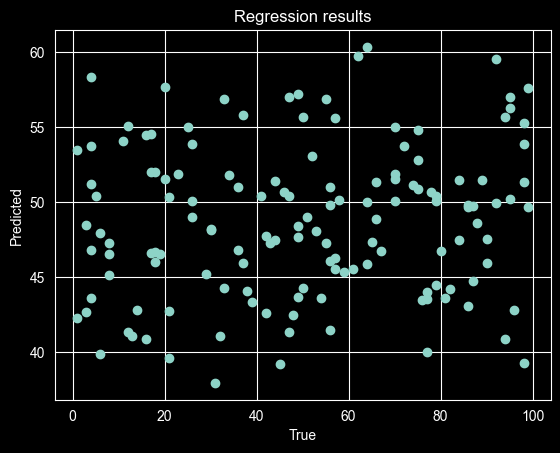

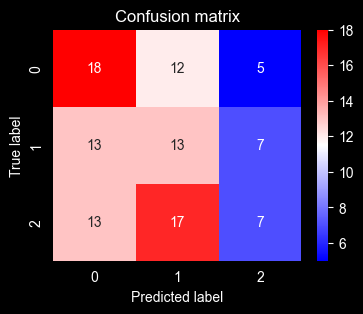

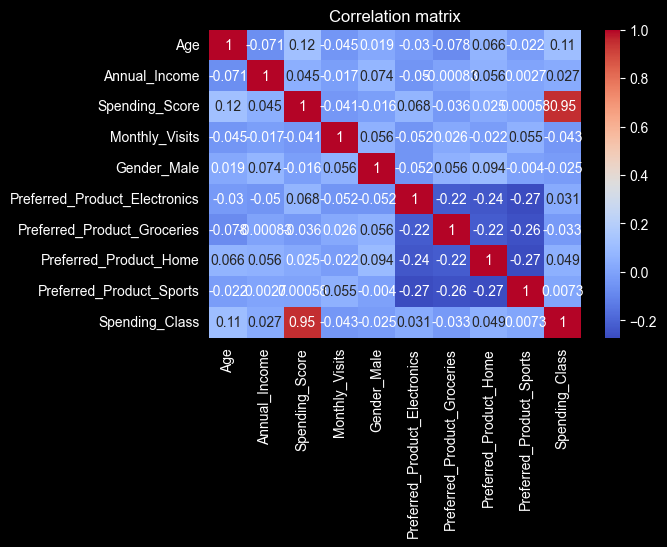

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import r2_score

df = pd.read_csv("customer_segmentation_mixed.csv")

df.info()
print(df.describe())
print()

numeric_columns = df.select_dtypes(include='number').columns
categorical_columns = df.select_dtypes(exclude='number').columns

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)
print()

# ЛАБ.1 Предобработка датасетв
print(df.isnull().sum())
print()

age_mean = df['Age'].mean()
income_mean = df['Annual_Income'].mean()
gender_mode = df['Gender'].mode()[0]
product_mode = df['Preferred_Product'].mode()[0]

df['Age'] = df['Age'].fillna(age_mean)
df['Annual_Income'] = df['Annual_Income'].fillna(income_mean)
df['Gender'] = df['Gender'].fillna(gender_mode)
df['Preferred_Product'] = df['Preferred_Product'].fillna(product_mode)

print(df.isnull().sum())

df = pd.get_dummies(df,
    columns=['Gender', 'Preferred_Product'],
    drop_first=True
)

print(df.head())
df.info()

# ЛАБ2. Регрессия и классификация
X_1 = df.drop('Spending_Score', axis=1)
y_1 = df['Spending_Score']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_1, y_1, test_size=0.4, random_state=42
)

# scaling для регрессии
scaler_reg = MinMaxScaler()
num_cols_reg = X_train_reg.select_dtypes(include='number').columns

scaler_reg.fit(X_train_reg[num_cols_reg])
X_train_reg[num_cols_reg] = scaler_reg.transform(X_train_reg[num_cols_reg])
X_test_reg[num_cols_reg] = scaler_reg.transform(X_test_reg[num_cols_reg])

linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)

y_pred_reg = linear_model.predict(X_test_reg)

plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Regression results")

print()
print("MSE:", mean_squared_error(y_test_reg, y_pred_reg))
print("RMSE:", root_mean_squared_error(y_test_reg, y_pred_reg))
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("R2:", r2_score(y_test_reg, y_pred_reg))

# Полиномиальная регрессия
poly = PolynomialFeatures(2)

X_train_poly = poly.fit_transform(X_train_reg)
X_test_poly = poly.transform(X_test_reg)

linear_model.fit(X_train_poly, y_train_reg)
y_pred_poly = linear_model.predict(X_test_poly)

ridge = Ridge(alpha=2.0)
ridge.fit(X_train_poly, y_train_reg)
y_pred_ridge = ridge.predict(X_test_poly)

print("Linear R2:", r2_score(y_test_reg, y_pred_reg))
print("Poly R2:", r2_score(y_test_reg, y_pred_poly))
print("Ridge R2:", r2_score(y_test_reg, y_pred_ridge))

# Классификация
df['Spending_Class'] = pd.cut(df['Spending_Score'], bins=3, labels=[0,1,2])
X_2 = df.drop(['Spending_Score', 'Spending_Class'], axis=1)
y_2 = df['Spending_Class']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_2, y_2, test_size=0.3, random_state=42
)

# scaling для классификации
scaler_clf = MinMaxScaler()
num_cols_clf = X_train_clf.select_dtypes(include='number').columns

scaler_clf.fit(X_train_clf[num_cols_clf])
X_train_clf[num_cols_clf] = scaler_clf.transform(X_train_clf[num_cols_clf])
X_test_clf[num_cols_clf] = scaler_clf.transform(X_test_clf[num_cols_clf])

logreg_model = LogisticRegression(max_iter=5000)
logreg_model.fit(X_train_clf, y_train_clf)

y_pred_class = logreg_model.predict(X_test_clf)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_class))
cm = confusion_matrix(y_test_clf, y_pred_class)
print(classification_report(y_test_clf, y_pred_class))

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='bwr')
plt.title('Confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
print(df['Spending_Class'].value_counts(normalize=True))

# Корреляция
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()